# Mini Projects: CartPole, FrozenLake, Q-learning, and DQN

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Q-learning algorithm
- Apply Q-learning to FrozenLake environment
- Apply Q-learning to CartPole environment (with state discretization)
- Understand Deep Q-Network (DQN) concepts
- Train and evaluate RL agents on classic environments

## 🔗 Prerequisites

- ✅ OpenAI Gym setup
- ✅ Understanding of states, actions, rewards
- ✅ Epsilon-Greedy exploration strategy
- ✅ Python knowledge (functions, classes, loops, dictionaries)
- ✅ NumPy knowledge
- ✅ Basic understanding of neural networks (for DQN section)

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- Mini projects: applying RL in games like CartPole and FrozenLake, implementing Q-learning and DQN

---

## Introduction

This notebook combines multiple mini projects:
1. **Q-learning on FrozenLake**: Classic grid-world problem with discrete states
2. **Q-learning on CartPole**: Continuous state space requiring discretization
3. **DQN Introduction**: Deep reinforcement learning for high-dimensional states

These projects demonstrate practical RL applications on classic benchmark environments.

## Lesson Brief

This lesson gives students a first practical bridge from small theory examples to recognizable RL tasks.

They will see how the same core ideas appear in environments like FrozenLake and CartPole, even when the implementation details become harder.

Why this matters: students often need one notebook that says, "This is what the theory looks like in a real benchmark."

This lesson is meant to increase confidence before later units go deeper.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Johnny Code - "Simply Explaining Deep Q-Learning/Deep Q-Network (DQN)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=EUrWGTCGzlA)

Why this pick:
- step-by-step coding explanation.
- Connects FrozenLake, epsilon-greedy, Q-tables, and DQN in one practical example.
- Good bridge from simple benchmark tasks to deeper RL methods.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Replay buffer: stored experiences for reuse.
- Target network: stabilizes targets.
- Mini-batch: a small training sample.
- Approximator: a neural network replacing the table.

### Quick Check
- Why does DQN need replay?
- Why use a target network?
- What does DQN solve that tabular methods cannot?

### Common Mistakes
- Focusing on network code but missing the algorithm idea.
- Thinking deep RL is unrelated to Q-learning.
- Ignoring stability as the main challenge.


## What you should learn from this notebook

This notebook is the bridge from Unit 1 theory to small practical experiments.

By the end, you should be able to:

- connect MDP ideas to simple environments
- understand the shape of a Q-learning workflow
- see why FrozenLake fits tabular RL well
- understand why CartPole is harder for tabular methods
- treat DQN as a preview of Unit 3, not as the main goal of Unit 1


### Step Guide

**What this cell does:** `%pip` installs Gymnasium, Torch (for the DQN preview), and plotting helpers used later.

**How to read it (weak Python OK):** Torch is large—expect a wait once. A coffee break is normal.

**What to expect in the output:** Pip progress and success prints.

**If you feel lost:** Do not run the DQN section until this cell succeeds without errors.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.
# Torch is included because the final DQN preview cell imports it explicitly.

# Line magic: Jupyter/IPython directive for this line only.
%pip install torch "gymnasium[classic-control]" numpy matplotlib ipywidgets pillow -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import random

# Readable defaults for plots (aligned with other Unit 1 example notebooks).
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
# Load a library so you can use its ready-made functions and types below.
from collections import defaultdict

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nMini Projects: CartPole, FrozenLake, Q-learning, and DQN")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


Note: you may need to restart the kernel to use updated packages.
✅ Libraries imported!

Mini Projects: CartPole, FrozenLake, Q-learning, and DQN


## Part 1: Q-Learning Algorithm Implementation


### Step Guide

**What this cell does:** **Part 1** — implements a tiny **tabular Q-learning** update loop on a discrete toy so you can see the Q-table change.

**How to read it (weak Python OK):** Think spreadsheet: rows = states, columns = actions, numbers = “how good seems taking this action here.”

**What to expect in the output:** Training logs and a heatmap or printed table of Q-values.

**If you feel lost:** Track only one state row across iterations—does the best action column brighten over time?


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Q-Learning Algorithm Implementation")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


# Function `q_learning_update` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: q_table, state, action, reward, next_state, alpha, gamma.
def q_learning_update(q_table, state, action, reward, next_state, alpha, gamma):
    # Save a value in a name so the next lines can read it.
    best_next = np.max(q_table[next_state])
    # Another assignment—same idea: store a value for the lines below.
    td_target = reward + gamma * best_next
    # Another assignment—same idea: store a value for the lines below.
    td_error = td_target - q_table[state, action]
    # Another assignment—same idea: store a value for the lines below.
    q_table[state, action] += alpha * td_error
    # Send a value back to whoever called this function.
    return q_table[state, action]


# Save a value in a name so the next lines can read it.
q_demo = np.zeros((5, 4))
# Another assignment—same idea: store a value for the lines below.
updated_value = q_learning_update(
    # Execute: q_demo,
    q_demo,
    # Create or choose a variable used in the Bellman warm-up demo.
    state=2,
    # Save a value in a name so the next lines can read it.
    action=1,
    # Unpack the one-step model output from transition(state, action).
    reward=10,
    # Unpack the one-step model output from transition(state, action).
    next_state=3,
    # Save a value in a name so the next lines can read it.
    alpha=0.1,
    # Another assignment—same idea: store a value for the lines below.
    gamma=0.9,
# Close the parentheses opened earlier (end this function call / grouping).
)

# Show text or numbers in the cell output area under the code.
print("A single Q-learning update example:")
# Show text or numbers in the cell output area under the code.
print("Updated Q[2, 1] =", round(updated_value, 3))
# Show text or numbers in the cell output area under the code.
print("\nCore idea:")
# Show text or numbers in the cell output area under the code.
print("Q-learning moves the current estimate toward reward + discounted best future value.")


Part 1: Q-Learning Algorithm Implementation
A single Q-learning update example:
Updated Q[2, 1] = 1.0

Core idea:
Q-learning moves the current estimate toward reward + discounted best future value.


## Part 2: Q-Learning on FrozenLake


### Step Guide

**What this cell does:** **Part 2** — runs Q-learning on **FrozenLake** (slippery grid) so you connect the table to a classic Gym env.

**How to read it (weak Python OK):** Compare success rate before vs after training—did the agent learn to avoid holes?

**What to expect in the output:** Episode rewards, rolling averages, maybe a policy map.

**If you feel lost:** If training is slow, lower episode counts in the config block first—small proof beats big waits.



Part 2: Q-Learning on FrozenLake


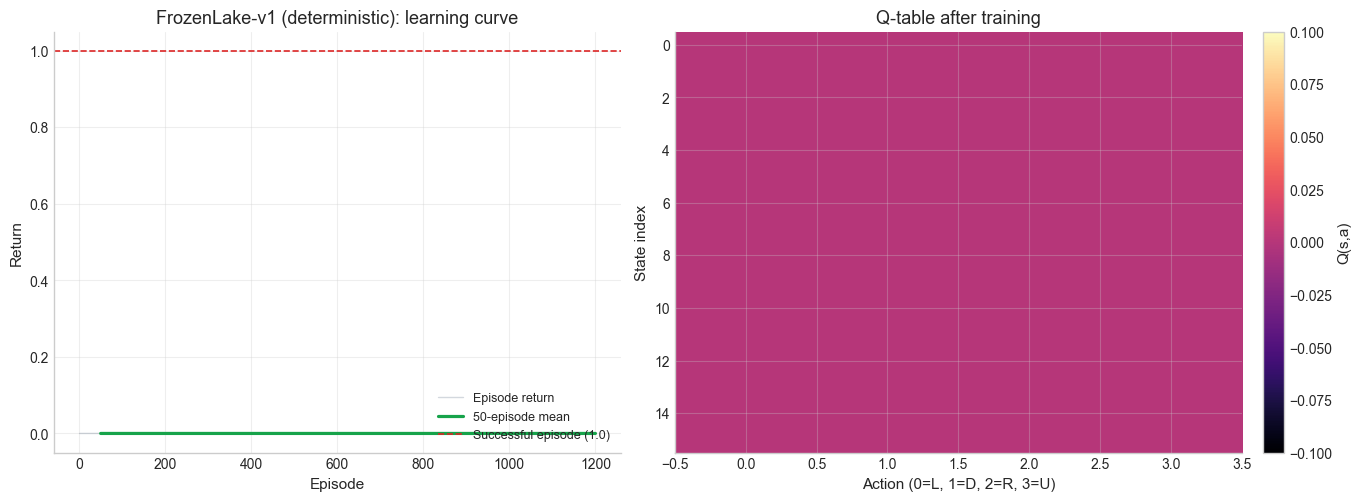

FrozenLake Q-table shape: (16, 4)
Average reward over last 100 episodes: 0.0
Final epsilon: 0.05

Why this example matters:
FrozenLake has a small discrete state space, so tabular Q-learning is a natural fit.
With enough episodes and decaying exploration, the agent should solve the deterministic map consistently.


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Q-Learning on FrozenLake")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
env = gym.make("FrozenLake-v1", is_slippery=False)
# Another assignment—same idea: store a value for the lines below.
q_table = np.zeros((env.observation_space.n, env.action_space.n))
# Another assignment—same idea: store a value for the lines below.
alpha = 0.1
# Another assignment—same idea: store a value for the lines below.
gamma = 0.95
# Another assignment—same idea: store a value for the lines below.
epsilon = 1.0
# Another assignment—same idea: store a value for the lines below.
epsilon_min = 0.05
# Another assignment—same idea: store a value for the lines below.
epsilon_decay = 0.995
# Unpack the one-step model output from transition(state, action).
rewards = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(1200):
    # Save a value in a name so the next lines can read it.
    state, info = env.reset(seed=episode)
    # Another assignment—same idea: store a value for the lines below.
    total_reward = 0
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(100):
        # If the condition is True, run the indented block under this line.
        if np.random.rand() < epsilon:
            # Save a value in a name so the next lines can read it.
            action = env.action_space.sample()
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            action = int(np.argmax(q_table[state]))

        # Unpack the one-step model output from transition(state, action).
        next_state, reward, terminated, truncated, info = env.step(action)
        # Execute: q_learning_update(q_table, state, action, reward, next_state, alpha, gamma)
        q_learning_update(q_table, state, action, reward, next_state, alpha, gamma)
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state
        # Save a value in a name so the next lines can read it.
        total_reward += reward
        # If the condition is True, run the indented block under this line.
        if terminated or truncated:
            # Stop the loop completely and continue after the loop block.
            break

    # Add one new item to the end of a list (the list grows in place).
    rewards.append(total_reward)
    # Save a value in a name so the next lines can read it.
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# Execute: env.close()
env.close()

# Save a value in a name so the next lines can read it.
recent_success = np.mean(rewards[-100:])

# Plots: episode returns + smoothed trend, and the learned Q-table (tabular RL "spreadsheet").
episodes_axis = np.arange(1, len(rewards) + 1)
smooth_window = 50
rolled = np.convolve(rewards, np.ones(smooth_window) / smooth_window, mode="valid")
roll_x = np.arange(smooth_window, len(rewards) + 1)
fig, (ax_r, ax_q) = plt.subplots(1, 2, figsize=(13.5, 4.9), constrained_layout=True)
ax_r.plot(episodes_axis, rewards, alpha=0.28, color="#64748b", label="Episode return", lw=1)
ax_r.plot(roll_x, rolled, color="#16a34a", lw=2.3, label=f"{smooth_window}-episode mean")
ax_r.axhline(1.0, color="#dc2626", ls="--", lw=1.2, label="Successful episode (1.0)")
ax_r.set_xlabel("Episode")
ax_r.set_ylabel("Return")
ax_r.set_title("FrozenLake-v1 (deterministic): learning curve")
ax_r.legend(loc="lower right", fontsize=9)
ax_r.grid(True, alpha=0.32)
im = ax_q.imshow(q_table, aspect="auto", cmap="magma", interpolation="nearest")
ax_q.set_xlabel("Action (0=L, 1=D, 2=R, 3=U)")
ax_q.set_ylabel("State index")
ax_q.set_title("Q-table after training")
fig.colorbar(im, ax=ax_q, fraction=0.046, pad=0.02, label="Q(s,a)")
plt.show()

# Show text or numbers in the cell output area under the code.
print("FrozenLake Q-table shape:", q_table.shape)
# Show text or numbers in the cell output area under the code.
print("Average reward over last 100 episodes:", round(recent_success, 3))
# Show text or numbers in the cell output area under the code.
print("Final epsilon:", round(epsilon, 3))
# Show text or numbers in the cell output area under the code.
print("\nWhy this example matters:")
# Show text or numbers in the cell output area under the code.
print("FrozenLake has a small discrete state space, so tabular Q-learning is a natural fit.")
# Show text or numbers in the cell output area under the code.
print("With enough episodes and decaying exploration, the agent should solve the deterministic map consistently.")


## Part 2b: Watch your greedy policy on FrozenLake (GIF + step slider)

**Prerequisite:** Run **Part 2** above so `q_table` is trained.

This replay uses a **greedy** policy: `action = argmax_a Q(state, a)` (no ε-random exploration). Use the **slider** to connect each timestep to the **grid render**, then try **▶** for autoplay.

Frames: 41 | return=0.0 | terminated=False | truncated=False

--- Greedy rollout GIF ---


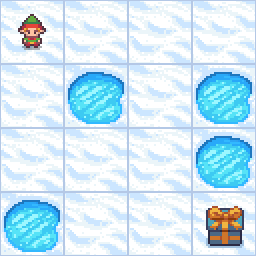


--- Scrub / autoplay ---


In [4]:
# Visualize the learned greedy policy as rgb frames (same map as Part 2: not slippery).

import pathlib
import sys

if "q_table" not in globals():
    raise RuntimeError("Run the Part 2 cell above first so `q_table` exists, then rerun this cell.")

_course09 = None
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
if _course09 is None:
    raise FileNotFoundError("Could not find course09_step_viz.py — open/run from inside Course 09.")
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import course09_step_viz as cs9viz

env_vis = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")


def greedy_policy(obs, step):
    s = int(obs)
    return int(np.argmax(q_table[s]))


frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, greedy_policy, max_steps=40, seed=123
)
env_vis.close()

print(f"Frames: {len(frames)} | return={total_r} | terminated={term} | truncated={trunc}")
print("\n--- Greedy rollout GIF ---")
cs9viz.display_gif(frames, duration_ms=220)
print("\n--- Scrub / autoplay ---")
cs9viz.display_step_slider(frames, title="FrozenLake-v1 timestep")

## Part 3: Q-Learning on CartPole (with State Discretization)


### Step Guide

**What this cell does:** **Part 3** — **discretizes CartPole** so tabular Q-learning can still run on a continuous observation env.

**How to read it (weak Python OK):** Discretization = “bucket similar numbers into the same bin.” That makes the spreadsheet finite again.

**What to expect in the output:** Training curves or average return prints for CartPole buckets.

**If you feel lost:** If buckets feel arbitrary, that is normal—here we only want the *idea* that continuity breaks pure tables.


In [5]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Q-Learning on CartPole (with State Discretization)")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
env = gym.make("CartPole-v1")
# Another assignment—same idea: store a value for the lines below.
obs, info = env.reset(seed=42)

# Show text or numbers in the cell output area under the code.
print("One CartPole observation:", obs)
# Show text or numbers in the cell output area under the code.
print("Observation dimension:", len(obs))
# Show text or numbers in the cell output area under the code.
print("Action space:", env.action_space)

# Execute: env.close()
env.close()

# Show text or numbers in the cell output area under the code.
print("\nWhy CartPole is harder than FrozenLake:")
# Show text or numbers in the cell output area under the code.
print("- CartPole observations are continuous, not small discrete state IDs.")
# Show text or numbers in the cell output area under the code.
print("- A plain Q-table does not directly fit this representation.")
# Show text or numbers in the cell output area under the code.
print("- One workaround is discretization, but that can be crude and inefficient.")
# Show text or numbers in the cell output area under the code.
print("- This motivates neural-network approaches such as DQN later.")



Part 3: Q-Learning on CartPole (with State Discretization)
One CartPole observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation dimension: 4
Action space: Discrete(2)

Why CartPole is harder than FrozenLake:
- CartPole observations are continuous, not small discrete state IDs.
- A plain Q-table does not directly fit this representation.
- One workaround is discretization, but that can be crude and inefficient.
- This motivates neural-network approaches such as DQN later.


## Part 4: Introduction to Deep Q-Network (DQN)


### Step Guide

**What this cell does:** **Part 4** — **DQN preview**: tiny network + training loop showing why neural nets help when tables explode.

**How to read it (weak Python OK):** You are not expected to master PyTorch yet—watch how `loss` moves and whether the pole stays up longer over episodes.

**What to expect in the output:** Loss traces, episodic returns, maybe a short animation hook.

**If you feel lost:** Treat Torch tensors as “fancy numpy arrays” and skip layer definitions on the first pass.


In [6]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 4: Introduction to Deep Q-Network (DQN)")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nDQN Overview:")
# Show text or numbers in the cell output area under the code.
print(" - Uses neural network to approximate Q-function (instead of Q-table)")
# Show text or numbers in the cell output area under the code.
print(" - Handles high-dimensional state spaces (e.g., images)")
# Show text or numbers in the cell output area under the code.
print(" - Key innovations:")
# Show text or numbers in the cell output area under the code.
print(" 1. Experience Replay: Store transitions, sample randomly for training")
# Show text or numbers in the cell output area under the code.
print(" 2. Target Network: Separate network for stable Q-targets")
# Show text or numbers in the cell output area under the code.
print(" 3. Neural Network: Approximate Q(s,a) for continuous/ high-dim states")

# Show text or numbers in the cell output area under the code.
print("\nDQN Architecture:")
# Show text or numbers in the cell output area under the code.
print(" Input: State (e.g., image, observation vector)")
# Show text or numbers in the cell output area under the code.
print(" Network: Fully connected or CNN layers")
# Show text or numbers in the cell output area under the code.
print(" Output: Q-values for each action")

# Show text or numbers in the cell output area under the code.
print("\nDQN vs Q-Learning:")
# Show text or numbers in the cell output area under the code.
print(" Q-Learning:")
# Show text or numbers in the cell output area under the code.
print(" - Uses Q-table (discrete states only)")
# Show text or numbers in the cell output area under the code.
print(" - Limited to small state spaces")
# Show text or numbers in the cell output area under the code.
print(" - Fast for tabular problems")
# Show text or numbers in the cell output area under the code.
print(" DQN:")
# Show text or numbers in the cell output area under the code.
print(" - Uses neural network (continuous/high-dim states)")
# Show text or numbers in the cell output area under the code.
print(" - Scales to complex problems (e.g., Atari games)")
# Show text or numbers in the cell output area under the code.
print(" - Requires more computation and tuning")

# Show text or numbers in the cell output area under the code.
print("\nDQN Algorithm (High-Level):")
# Show text or numbers in the cell output area under the code.
print(" 1. Initialize Q-network and target network")
# Show text or numbers in the cell output area under the code.
print(" 2. For each episode:")
# Show text or numbers in the cell output area under the code.
print(" a. Observe state")
# Show text or numbers in the cell output area under the code.
print(" b. Choose action using epsilon-greedy (using Q-network)")
# Show text or numbers in the cell output area under the code.
print(" c. Take action, store transition in replay buffer")
# Show text or numbers in the cell output area under the code.
print(" d. Sample batch from replay buffer")
# Show text or numbers in the cell output area under the code.
print(" e. Compute targets using target network")
# Show text or numbers in the cell output area under the code.
print(" f. Update Q-network using loss: (Q(s,a) - target)^2")
# Show text or numbers in the cell output area under the code.
print(" g. Periodically update target network")

# Show text or numbers in the cell output area under the code.
print("\nNote: Full DQN implementation will be covered in Unit 3 (Deep RL)")
# Show text or numbers in the cell output area under the code.
print("This is an introduction to the concepts.")

# Show text or numbers in the cell output area under the code.
print("\n✅ DQN introduction complete!")



Part 4: Introduction to Deep Q-Network (DQN)

DQN Overview:
 - Uses neural network to approximate Q-function (instead of Q-table)
 - Handles high-dimensional state spaces (e.g., images)
 - Key innovations:
 1. Experience Replay: Store transitions, sample randomly for training
 2. Target Network: Separate network for stable Q-targets
 3. Neural Network: Approximate Q(s,a) for continuous/ high-dim states

DQN Architecture:
 Input: State (e.g., image, observation vector)
 Network: Fully connected or CNN layers
 Output: Q-values for each action

DQN vs Q-Learning:
 Q-Learning:
 - Uses Q-table (discrete states only)
 - Limited to small state spaces
 - Fast for tabular problems
 DQN:
 - Uses neural network (continuous/high-dim states)
 - Scales to complex problems (e.g., Atari games)
 - Requires more computation and tuning

DQN Algorithm (High-Level):
 1. Initialize Q-network and target network
 2. For each episode:
 a. Observe state
 b. Choose action using epsilon-greedy (using Q-network)


## Preview Only: Why DQN appears next

At this point in the course, the goal is **not** to master deep RL yet.

This section is only a preview showing why DQN becomes necessary:

- CartPole observations are continuous
- tabular Q-learning does not scale well here
- neural networks can approximate action values from raw observations

Full DQN treatment belongs to Unit 3.

### Step Guide

**What this cell does:** Loads **Torch** modules explicitly for the DQN preview (after the markdown warning about preview-only scope).

**How to read it (weak Python OK):** If you are skipping deep RL for now, you may still run this to avoid `ModuleNotFoundError` later.

**What to expect in the output:** Silent import success.

**If you feel lost:** This pairs with the markdown cell above it—read that blurb before the imports.


Episode   0 | Avg reward (last 30): 28.0 | ε=0.995
Episode  30 | Avg reward (last 30): 22.4 | ε=0.856
Episode  60 | Avg reward (last 30): 21.8 | ε=0.737
Episode  90 | Avg reward (last 30): 24.6 | ε=0.634
Episode 120 | Avg reward (last 30): 24.1 | ε=0.545
Episode 150 | Avg reward (last 30): 24.9 | ε=0.469
Episode 180 | Avg reward (last 30): 42.1 | ε=0.404
Episode 210 | Avg reward (last 30): 35.9 | ε=0.347
Episode 240 | Avg reward (last 30): 43.2 | ε=0.299
Episode 270 | Avg reward (last 30): 53.6 | ε=0.257


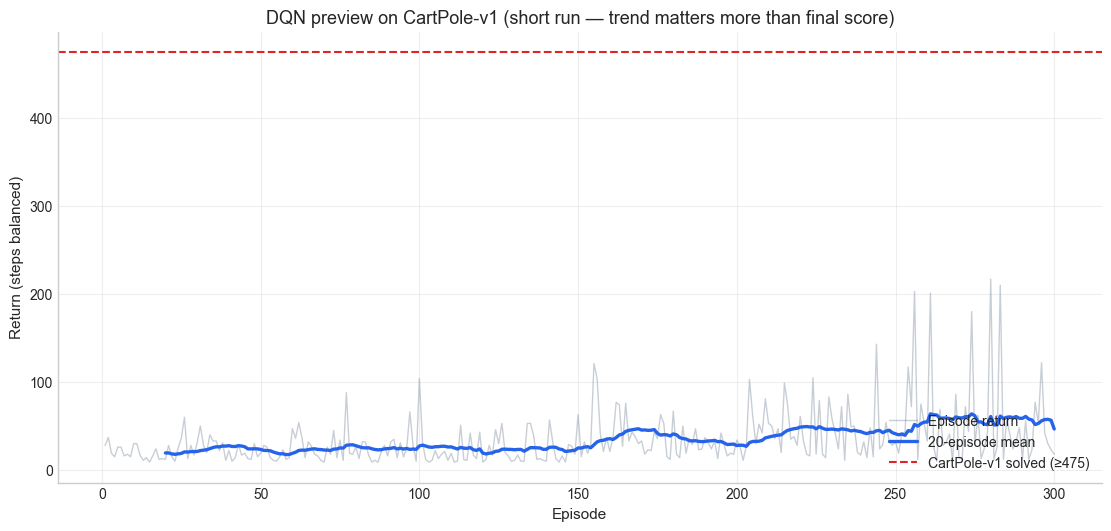

In [7]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, random, collections, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42); np.random.seed(42)

# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')

# ── DQN Network ──────────────────────────────────────────────────────────
# Class `DQN` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class DQN(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, obs, act.
    def __init__(self, obs=4, act=2):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, act)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy_net = DQN(); target_net = DQN()
# Execute: target_net.load_state_dict(policy_net.state_dict())
target_net.load_state_dict(policy_net.state_dict())
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
# Another assignment—same idea: store a value for the lines below.
memory  = collections.deque(maxlen=10000)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
# Save a value in a name so the next lines can read it.
BATCH   = 64; rewards_ep = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(300):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); total_r = 0
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(500):
        # If the condition is True, run the indented block under this line.
        if random.random() < EPS:
            # Save a value in a name so the next lines can read it.
            action = env.action_space.sample()
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        # Another assignment—same idea: store a value for the lines below.
        obs2, r, done, trunc, _ = env.step(action)
        # Add one new item to the end of a list (the list grows in place).
        memory.append((obs, action, r, obs2, done or trunc))
        # Save a value in a name so the next lines can read it.
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        # If the condition is True, run the indented block under this line.
        if len(memory) >= BATCH:
            # Save a value in a name so the next lines can read it.
            batch = random.sample(memory, BATCH)
            # Another assignment—same idea: store a value for the lines below.
            s,a,r_b,s2,d = zip(*batch)
            # Another assignment—same idea: store a value for the lines below.
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            # Another assignment—same idea: store a value for the lines below.
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            # Another assignment—same idea: store a value for the lines below.
            D=torch.tensor(d).float()
            # Another assignment—same idea: store a value for the lines below.
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                Q_next = target_net(S2).max(1)[0]
            # Another assignment—same idea: store a value for the lines below.
            Q_target = R + GAMMA*Q_next*(1-D)
            # Another assignment—same idea: store a value for the lines below.
            loss = nn.MSELoss()(Q_pred, Q_target)
            # Execute: opt.zero_grad(); loss.backward(); opt.step()
            opt.zero_grad(); loss.backward(); opt.step()
        # If the condition is True, run the indented block under this line.
        if done or trunc: break
    # Save a value in a name so the next lines can read it.
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    # Add one new item to the end of a list (the list grows in place).
    rewards_ep.append(total_r)
    # If the condition is True, run the indented block under this line.
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    # If the condition is True, run the indented block under this line.
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

# Execute: env.close()
env.close()

# Reward plot: noisy returns + smoothed curve + Gymnasium "solved" threshold for CartPole-v1.
ep_idx = np.arange(1, len(rewards_ep) + 1)
win = 20
smooth = np.convolve(rewards_ep, np.ones(win) / win, mode="valid")
smooth_x = np.arange(win, len(rewards_ep) + 1)
fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
ax.plot(ep_idx, rewards_ep, alpha=0.35, color="#64748b", lw=1, label="Episode return")
ax.plot(smooth_x, smooth, color="#2563eb", lw=2.4, label=f"{win}-episode mean")
ax.axhline(475.0, color="#dc2626", ls="--", lw=1.5, label="CartPole-v1 solved (≥475)")
ax.set_xlabel("Episode")
ax.set_ylabel("Return (steps balanced)")
ax.set_title("DQN preview on CartPole-v1 (short run — trend matters more than final score)")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.32)
plt.show()


## Summary

This notebook connected Unit 1 theory to small practical experiments.

### Main takeaways

- Q-learning updates action values from reward and estimated future value.
- FrozenLake is a friendly first environment for tabular RL.
- CartPole is harder because the observation space is continuous.
- DQN is introduced here only as a preview of the next level of RL methods.

### What should be mastered now

At the end of Unit 1, students should be comfortable with:

- the RL interaction loop
- states, actions, rewards, and policies
- simple tabular updates
- why some environments are easy for tables and others are not

### What can wait until later

The details of replay buffers, target networks, and deep RL training stability belong to Unit 3.

In [8]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Papers
- Watkins & Dayan (1992) — [Q-Learning](https://link.springer.com/article/10.1007/BF00992698)
- Mnih et al. (2015) — [DQN: Human-level control via deep RL](https://www.nature.com/articles/nature14236)
- Van Hasselt et al. (2016) — [Double DQN](https://arxiv.org/abs/1509.06461)

**OpenAI Gym:** [Gymnasium Documentation](https://gymnasium.farama.org/)

### State-of-the-art DQN variants power game-playing AI and robotics controllers at Google DeepMind.
"""))


## 📚 References & Further Reading

### Papers
- Watkins & Dayan (1992) — [Q-Learning](https://link.springer.com/article/10.1007/BF00992698)
- Mnih et al. (2015) — [DQN: Human-level control via deep RL](https://www.nature.com/articles/nature14236)
- Van Hasselt et al. (2016) — [Double DQN](https://arxiv.org/abs/1509.06461)

**OpenAI Gym:** [Gymnasium Documentation](https://gymnasium.farama.org/)

### State-of-the-art DQN variants power game-playing AI and robotics controllers at Google DeepMind.


### Step Guide

**What this cell does:** Optional **auto-plots** for metrics gathered in the mini projects (returns, lengths, etc.).

**How to read it (weak Python OK):** Compare curves across parts: tabular vs discretized vs neural.

**What to expect in the output:** Charts or a gentle no-op.

**If you feel lost:** Re-run the part you care about so variables exist, then execute this recap cell.


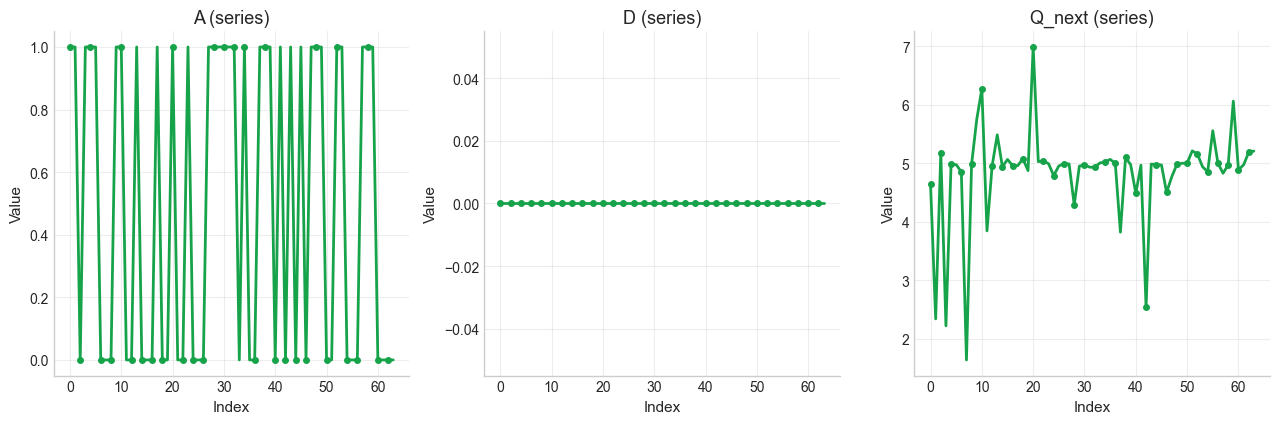

In [9]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Match other Unit 1 notebooks: light grid, readable type, no top/right spines.
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(
        summary.keys(),
        summary.values(),
        color=["#2563eb", "#16a34a", "#f59e0b"],
        edgecolor="#0f172a",
        linewidth=0.65,
    )
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.35)
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig_w = max(11.0, 4.3 * len(candidates))
    fig, axes = plt.subplots(1, len(candidates), figsize=(fig_w, 4.35))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(
                range(len(values)),
                values,
                color="#2563eb",
                edgecolor="#0f172a",
                linewidth=0.55,
            )
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=40, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
            ax.grid(True, axis="y", alpha=0.35)
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            n = len(payload)
            markevery = max(1, n // 25) if n > 40 else 1
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(
                payload,
                marker="o",
                markersize=4,
                markevery=markevery,
                linewidth=2,
                color="#16a34a",
            )
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
            ax.grid(True, alpha=0.35)
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(
                payload,
                aspect="auto",
                cmap="viridis",
                interpolation="nearest",
            )
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Mini-projects help students connect theory to practice by showing how environment choice, algorithm choice, and debugging fit together.

**If students remember one idea:** A project is not only about getting a score. It is about explaining why a method fits a task and how to evaluate it.

**Quick check before moving on:**
- Can you explain why one project may suit tabular methods while another may need deep RL?
- Can you describe what you would monitor while testing a simple RL mini-project?

**Bridge to the next step:** This closes Unit 1 and prepares students for classical prediction and control algorithms in Unit 2.

**For weaker coders:** The big fork is **small table of states** (Q-learning) vs **huge sensor vectors** (DQN). If you can explain that sentence, Unit 1 clicked.


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
